In [1]:
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
import tkinter as tk
from tkinter import filedialog, messagebox
import pandas as pd
config = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}
import numpy as np

def MAS(df, M, A, method, alpha, logFC_threshold, up_or_down_or_both):
    if method == 'PValue':
        y_column = 'PValue'
    elif method == 'BH':
        df['BH_adjusted_p-value'] = BH_adjusted_pvalue(df['PValue'].values, alpha)
        y_column = 'BH_adjusted_p-value'
    elif method == 'Bonferroni':
        n_tests = len(df)
        df['Bonferroni_adjusted_p-value'] = np.minimum(df['PValue'] * n_tests, 1.0)
        y_column = 'Bonferroni_adjusted_p-value'
    elif method == 'BY':
        df['BY_adjusted_p-value'] = BY_adjusted_pvalue(df['PValue'].values, alpha)
        y_column = 'BY_adjusted_p-value'
    elif method == 'Holm':
        df['Holm_adjusted_p-value'] = Holm_adjusted_pvalue(df['PValue'].values, alpha)
        y_column = 'Holm_adjusted_p-value'
    elif method == 'Hochberg':
        df['Hochberg_adjusted_p-value'] = Hochberg_adjusted_pvalue(df['PValue'].values, alpha)
        y_column = 'Hochberg_adjusted_p-value'
    else:
        y_column = 'PValue'
    df[y_column] = df[y_column].clip(upper=1)
    adjusted_alpha = alpha / len(df) if method == 'Bonferroni' else alpha
    if up_or_down_or_both == 'Only_upregulated':
        df['MAS_Score'] = np.where((df['logFC'] > logFC_threshold) & (df[y_column] <= adjusted_alpha), np.abs(df['logFC']) ** M * np.abs(-np.log10(df[y_column])) ** A, 0)
    elif up_or_down_or_both == 'Only_downregulated':
        df['MAS_Score'] = np.where((df['logFC'] < -logFC_threshold) & (df[y_column] <= adjusted_alpha), np.abs(df['logFC']) ** M * np.abs(-np.log10(df[y_column])) ** A, 0)
    elif up_or_down_or_both == 'both_up_and_down_regulated':
        df['MAS_Score'] = np.where((df['logFC'].abs() > logFC_threshold) & (df[y_column] <= adjusted_alpha), np.abs(df['logFC']) ** M * np.abs(-np.log10(df[y_column])) ** A, 0)
    df = df.sort_values(by='MAS_Score', ascending=False).reset_index(drop=True)
    df['MAS_rank'] = df.index + 1
    return df

def BH_adjusted_pvalue(p, alpha):
    sort = np.argsort(p)
    rank = np.zeros(len(p))
    j = 1
    for i in range(len(sort)):
        rank[sort[i]] = j
        j = j + 1
    new_alpha = rank / len(p) * alpha
    L = []
    for j in range(len(rank)):
        if p[np.where(rank == len(rank) - j)[0][0]] < new_alpha[np.where(rank == len(rank) - j)[0][0]]:
            L.append(np.where(rank == len(rank) - j)[0][0])
    new_p = p * (len(p) / rank)
    H = np.zeros(len(p))
    H[np.where(rank == len(p))[0][0]] = new_p[np.where(rank == len(p))[0][0]]
    for k in range(1, len(p)):
        if new_p[np.where(rank == len(p) - k)[0][0]] > new_p[np.where(rank == len(p) - k + 1)[0][0]]:
            H[np.where(rank == len(p) - k)[0][0]] = new_p[np.where(rank == len(p) - k + 1)[0][0]]
        else:
            H[np.where(rank == len(p) - k)[0][0]] = new_p[np.where(rank == len(p) - k)[0][0]]
    BH_adjusted_p_values = np.where(H > 1, 1, H)
    return BH_adjusted_p_values
from matplotlib.ticker import MaxNLocator
import numpy as np
import matplotlib.pyplot as plt


In [2]:
import pandas as pd
from itertools import combinations

def rank_genes(df, gene_set, ranking_method='MAS'):
    if ranking_method not in ['MAS', 'corner_distance']:
        raise ValueError("Ranking method should be 'MAS' or 'corner_distance'")
    score_field = 'MAS_Score' if ranking_method == 'MAS' else 'corner_distance'
    ranked_genes = df[df['Gene Symbol'].isin(gene_set)].copy()
    if ranking_method == 'MAS':
        ranked_genes = ranked_genes.nlargest(10, score_field)
    else:
        ranked_genes = ranked_genes.nsmallest(10, score_field)
    return ranked_genes['Gene Symbol'].tolist()
import pandas as pd
from itertools import combinations
import pandas as pd
from itertools import combinations


In [3]:
data1 = pd.read_csv('GSE152418-original.csv')
data1.set_index('Gene Symbol', inplace=True)


In [4]:
new_columns = []
control_count = 1
sarscov2_count = 1
for col in data1.columns:
    if col.startswith('Healthy'):
        new_columns.append(f'Control ({control_count})')
        control_count += 1
    else:
        new_columns.append(f'SARS-CoV-2 ({sarscov2_count})')
        sarscov2_count += 1
data1.columns = new_columns


In [5]:
control_cols = [col for col in data1.columns if col.startswith('Control')]
sars_cols = [col for col in data1.columns if not col.startswith('Control')]
data1 = data1[control_cols + sars_cols]


In [6]:
data1.to_csv('GSE152418-Clean.csv', index=True)


In [7]:
data2 = pd.read_csv('GSE161731-original.csv')
data2.set_index('Gene Symbol', inplace=True)


In [8]:
group_map = data2.columns.str.extract('^([\\w\\s]+?)\\s*\\(')[0]
group_map.index = data2.columns
grouped_dataframes = {group: data2.loc[:, group_map[group_map == group].index].copy() for group in group_map.unique()}


In [9]:
combined_df = pd.concat([grouped_dataframes['HLTY'], grouped_dataframes['SARS_CoV_2_Yes']], axis=1)
combined_df.index.name = 'Gene Symbol'


In [10]:
new_columns = []
control_count = 1
sarscov2_count = 1
for col in combined_df.columns:
    if col.startswith('HLTY'):
        new_columns.append(f'Control ({control_count})')
        control_count += 1
    else:
        new_columns.append(f'SARS-CoV-2 ({sarscov2_count})')
        sarscov2_count += 1
combined_df.columns = new_columns


In [11]:
combined_df.to_csv('GSE161731-Clean.csv', index=True)


In [12]:
data3 = pd.read_csv('GSE171110-original.csv')
data3.set_index('Gene Symbol', inplace=True)


In [13]:
new_columns = []
control_count = 1
sarscov2_count = 1
for col in data3.columns:
    if col.startswith('HLTY'):
        new_columns.append(f'Control ({control_count})')
        control_count += 1
    else:
        new_columns.append(f'SARS-CoV-2 ({sarscov2_count})')
        sarscov2_count += 1
data3.columns = new_columns


In [14]:
data3.to_csv('GSE171110-Clean.csv', index=True)


In [15]:
data4 = pd.read_csv('PMC8202013-original.csv')
data4.set_index('Gene Symbol', inplace=True)


In [16]:
group_map = data4.columns.str.extract('^([\\w\\s]+?)\\s*\\(')[0]
group_map.index = data4.columns
grouped_dataframes = {group: data4.loc[:, group_map[group_map == group].index].copy() for group in group_map.unique()}


In [17]:
combined_df = pd.concat([grouped_dataframes['HLTY'], grouped_dataframes['SARS_CoV_2']], axis=1)
combined_df.index.name = 'Gene Symbol'


In [18]:
new_columns = []
control_count = 1
sarscov2_count = 1
for col in combined_df.columns:
    if col.startswith('HLTY'):
        new_columns.append(f'Control ({control_count})')
        control_count += 1
    else:
        new_columns.append(f'SARS-CoV-2 ({sarscov2_count})')
        sarscov2_count += 1
combined_df.columns = new_columns


In [19]:
combined_df.to_csv('PMC8202013-Clean.csv', index=True)


In [20]:
import pandas as pd
filenames = ['GSE152418-Clean.csv', 'GSE161731-Clean.csv', 'GSE171110-Clean.csv', 'PMC8202013-Clean.csv']
dataframes = {}
for fname in filenames:
    df = pd.read_csv(fname)
    df = df.drop_duplicates(subset='Gene Symbol')
    df.set_index('Gene Symbol', inplace=True)
    dataframes[fname] = df
common_genes = set.intersection(*(set(df.index) for df in dataframes.values()))
for fname, df in dataframes.items():
    filtered_df = df.loc[sorted(common_genes)]
    new_name = fname.replace('-Clean', '-Ready')
    filtered_df.to_csv(new_name)


In [21]:
import subprocess

def run_r_script():
    command = ['Rscript', 'TMM_GLMQL.R']
    result = subprocess.run(command, stdout=subprocess.PIPE, stderr=subprocess.PIPE, universal_newlines=True)
    if result.stdout:
        print('R script output:', result.stdout)
    if result.stderr:
        print('R script errors:', result.stderr)
if __name__ == '__main__':
    run_r_script()


R script output: [1] "Starting script execution."
[1] "Script has started running."
[1] "Guideline"
Script continues...
[1] "An error occurred: file choice cancelled"

R script errors: Loading required package: limma
Warning message:
package 'rstudioapi' was built under R version 4.3.3 



In [22]:
import subprocess

def run_r_script():
    command = ['Rscript', 'DESeq2.R']
    result = subprocess.run(command, stdout=subprocess.PIPE, stderr=subprocess.PIPE, universal_newlines=True)
    if result.stdout:
        print('R script output:', result.stdout)
    if result.stderr:
        print('R script errors:', result.stderr)
if __name__ == '__main__':
    run_r_script()


R script output: [1] "Starting script execution."
[1] "An error occurred: there is no package called 'DESeq2'"



In [23]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score
datasets = ['GSE152418', 'GSE161731', 'GSE171110', 'PMC8202013']

def load_sig_genes(tool, dataset):
    df = pd.read_csv(f'{tool}-{dataset}.csv')
    df = df[(df['Bonferroni_pvalue'] < 0.05) & (abs(df['logFC']) > 1)]
    return set(df['GeneSymbol'])

def evaluate_pca(common_genes, raw_file):
    raw_df = pd.read_csv(raw_file)
    raw_df.set_index('Gene Symbol', inplace=True)
    raw_df = raw_df.loc[raw_df.index.intersection(common_genes)]
    data = raw_df.T
    labels = data.index.str.contains('SARS-CoV-2').astype(int)
    scaler = StandardScaler()
    scaled = scaler.fit_transform(data)
    pcs = PCA(n_components=2).fit_transform(scaled)
    pc1 = pcs[:, 0]
    pred = (pc1 > np.median(pc1)).astype(int)
    auc = roc_auc_score(labels, pc1)
    precision = precision_score(labels, pred)
    recall = recall_score(labels, pred)
    return (auc, precision, recall)
results = []
for tool in ['DESeq2', 'EdgeR']:
    for test in datasets:
        train = [d for d in datasets if d != test]
        common_genes = set.intersection(*[load_sig_genes(tool, d) for d in train])
        auc, prec, rec = evaluate_pca(common_genes, f'{datasets.index(test) + 1}-{test}-Ready.csv')
        results.append({'Tool': tool, 'TestSet': test, 'NumGenes': len(common_genes), 'AUC': auc, 'Precision': prec, 'Recall': rec})
results_df = pd.DataFrame(results)
results_df.to_csv('CrossValidation_EdgeR_DESeq2_PCA.csv', index=False)
print(results_df)


     Tool     TestSet  NumGenes       AUC  Precision    Recall
0  DESeq2   GSE152418       129  1.000000   1.000000  1.000000
1  DESeq2   GSE161731       275  0.932292   0.785714  0.916667
2  DESeq2   GSE171110        99  0.995455   1.000000  0.613636
3  DESeq2  PMC8202013       110  0.948939   1.000000  0.631068
4   EdgeR   GSE152418        78  1.000000   1.000000  1.000000
5   EdgeR   GSE161731       195  0.932292   0.785714  0.916667
6   EdgeR   GSE171110        78  0.995455   1.000000  0.613636
7   EdgeR  PMC8202013        76  0.957210   1.000000  0.631068


In [24]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score
datasets = ['GSE152418', 'GSE161731', 'GSE171110', 'PMC8202013']

def load_sig_genes(tool, dataset):
    df = pd.read_csv(f'{tool}-{dataset}.csv')
    df = df[(df['FDR'] < 0.05) & (abs(df['logFC']) > 1)]
    return set(df['GeneSymbol'])

def evaluate_pca(genes, raw_file):
    raw_df = pd.read_csv(raw_file)
    raw_df.set_index('Gene Symbol', inplace=True)
    raw_df = raw_df.loc[raw_df.index.intersection(genes)]
    if raw_df.shape[0] < 2:
        return (np.nan, np.nan, np.nan, raw_df.shape[0])
    data = raw_df.T
    labels = data.index.str.contains('SARS-CoV-2').astype(int)
    scaler = StandardScaler()
    scaled = scaler.fit_transform(data)
    pcs = PCA(n_components=2).fit_transform(scaled)
    pc1 = pcs[:, 0]
    pred = (pc1 > np.median(pc1)).astype(int)
    auc = roc_auc_score(labels, pc1)
    precision = precision_score(labels, pred)
    recall = recall_score(labels, pred)
    return (auc, precision, recall, raw_df.shape[0])
results = []
for tool in ['DESeq2', 'EdgeR']:
    other = 'EdgeR' if tool == 'DESeq2' else 'DESeq2'
    for test_set in datasets:
        train_sets = [d for d in datasets if d != test_set]
        tool_genes = set.intersection(*[load_sig_genes(tool, d) for d in train_sets])
        other_genes = set.intersection(*[load_sig_genes(other, d) for d in train_sets])
        unique_genes = tool_genes - other_genes
        test_index = datasets.index(test_set) + 1
        raw_file = f'{test_index}-{test_set}-Ready.csv'
        auc, prec, rec, n_genes = evaluate_pca(unique_genes, raw_file)
        results.append({'Tool': tool, 'TestSet': test_set, 'NumGenes': n_genes, 'AUC': auc, 'Precision': prec, 'Recall': rec})
df_results = pd.DataFrame(results)
df_results.to_csv('UniqueCommonGenes_EdgeR_DESeq2.csv', index=False)
print(df_results)


     Tool     TestSet  NumGenes       AUC  Precision    Recall
0  DESeq2   GSE152418        31  0.783088   0.750000  0.750000
1  DESeq2   GSE161731        20  0.932292   0.785714  0.916667
2  DESeq2   GSE171110        14  0.984091   1.000000  0.613636
3  DESeq2  PMC8202013        17  0.923409   1.000000  0.631068
4   EdgeR   GSE152418        65  1.000000   1.000000  1.000000
5   EdgeR   GSE161731        21  0.979167   0.785714  0.916667
6   EdgeR   GSE171110        52  0.997727   1.000000  0.613636
7   EdgeR  PMC8202013        65  0.976268   1.000000  0.631068


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from scipy import interp
tools = ['DESeq2', 'EdgeR']
fpr_grid = np.linspace(0, 1, 100)
roc_data = {tool: [] for tool in tools}
for tool in tools:
    other = 'EdgeR' if tool == 'DESeq2' else 'DESeq2'
    for test_set in datasets:
        train_sets = [d for d in datasets if d != test_set]
        tool_genes = set.intersection(*[load_sig_genes(tool, d) for d in train_sets])
        other_genes = set.intersection(*[load_sig_genes(other, d) for d in train_sets])
        unique_genes = tool_genes - other_genes
        test_index = datasets.index(test_set) + 1
        raw_file = f'{test_index}-{test_set}-Ready.csv'
        auc, prec, rec, n_genes, y_true, y_score = evaluate_pca(unique_genes, raw_file)
        if y_true is not None:
            fpr, tpr, _ = roc_curve(y_true, y_score)
            tpr_interp = np.interp(fpr_grid, fpr, tpr)
            roc_data[tool].append(tpr_interp)
plt.figure(figsize=(8, 6))
colors = {'DESeq2': 'darkred', 'EdgeR': 'blue'}
for tool in tools:
    tprs = np.array(roc_data[tool])
    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)
    plt.plot(fpr_grid, mean_tpr, label=tool, color=colors[tool], lw=2)
    plt.fill_between(fpr_grid, mean_tpr - std_tpr, mean_tpr + std_tpr, color=colors[tool], alpha=0.2)
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curves Across Folds (Tool-Unique Genes)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


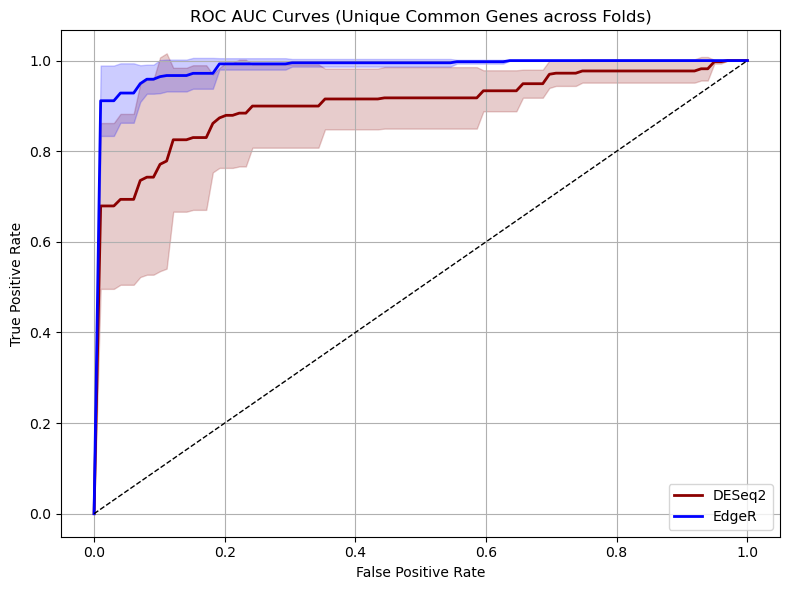

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve
datasets = ['GSE152418', 'GSE161731', 'GSE171110', 'PMC8202013']

def load_sig_genes(tool, dataset):
    df = pd.read_csv(f'{tool}-{dataset}.csv')
    df = df[(df['FDR'] < 0.05) & (abs(df['logFC']) > 1)]
    return set(df['GeneSymbol'])

def evaluate_pca(genes, raw_file):
    raw_df = pd.read_csv(raw_file)
    raw_df.set_index('Gene Symbol', inplace=True)
    raw_df = raw_df.loc[raw_df.index.intersection(genes)]
    if raw_df.shape[0] < 2:
        return (np.nan, np.nan, np.nan, raw_df.shape[0], None, None)
    data = raw_df.T
    labels = data.index.str.contains('SARS-CoV-2').astype(int)
    scaler = StandardScaler()
    scaled = scaler.fit_transform(data)
    pcs = PCA(n_components=2).fit_transform(scaled)
    pc1 = pcs[:, 0]
    pred = (pc1 > np.median(pc1)).astype(int)
    auc = roc_auc_score(labels, pc1)
    precision = precision_score(labels, pred)
    recall = recall_score(labels, pred)
    return (auc, precision, recall, raw_df.shape[0], labels, pc1)
tools = ['DESeq2', 'EdgeR']
fpr_grid = np.linspace(0, 1, 100)
roc_data = {tool: [] for tool in tools}
for tool in tools:
    other = 'EdgeR' if tool == 'DESeq2' else 'DESeq2'
    for test_set in datasets:
        train_sets = [d for d in datasets if d != test_set]
        tool_genes = set.intersection(*[load_sig_genes(tool, d) for d in train_sets])
        other_genes = set.intersection(*[load_sig_genes(other, d) for d in train_sets])
        unique_genes = tool_genes - other_genes
        test_index = datasets.index(test_set) + 1
        raw_file = f'{test_index}-{test_set}-Ready.csv'
        auc, prec, rec, n_genes, y_true, y_score = evaluate_pca(unique_genes, raw_file)
        if y_true is not None:
            fpr, tpr, _ = roc_curve(y_true, y_score)
            tpr_interp = np.interp(fpr_grid, fpr, tpr)
            tpr_interp[0] = 0.0
            tpr_interp[-1] = 1.0
            roc_data[tool].append(tpr_interp)
plt.figure(figsize=(8, 6))
colors = {'DESeq2': 'darkred', 'EdgeR': 'blue'}
for tool in tools:
    tprs = np.array(roc_data[tool])
    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)
    plt.plot(fpr_grid, mean_tpr, label=tool, color=colors[tool], lw=2)
    plt.fill_between(fpr_grid, mean_tpr - std_tpr, mean_tpr + std_tpr, color=colors[tool], alpha=0.2)
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curves (Unique Common Genes across Folds)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


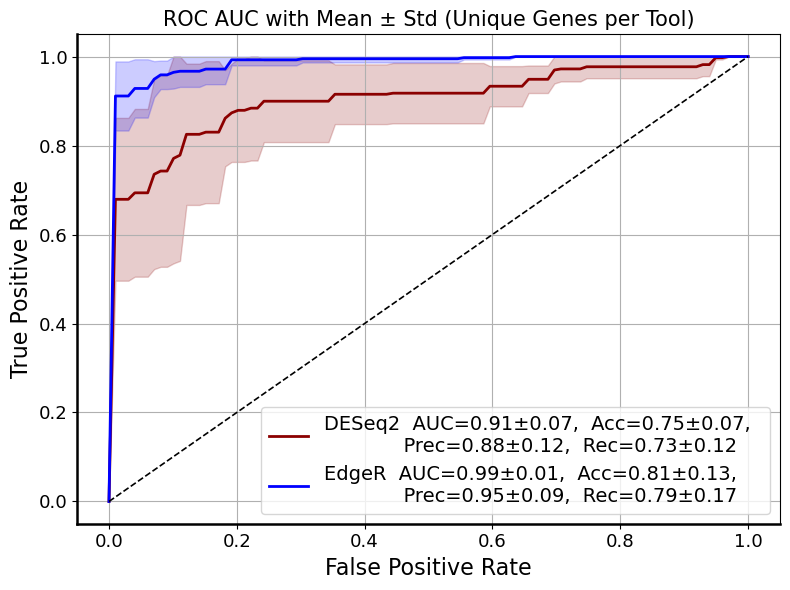

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score, roc_curve
datasets = ['GSE152418', 'GSE161731', 'GSE171110', 'PMC8202013']

def load_sig_genes(tool, dataset):
    df = pd.read_csv(f'{tool}-{dataset}.csv')
    df = df[(df['FDR'] < 0.05) & (abs(df['logFC']) > 1)]
    return set(df['GeneSymbol'])

def evaluate_pca(genes, raw_file):
    raw_df = pd.read_csv(raw_file)
    raw_df.set_index('Gene Symbol', inplace=True)
    raw_df = raw_df.loc[raw_df.index.intersection(genes)]
    if raw_df.shape[0] < 2:
        return (np.nan, np.nan, np.nan, np.nan, raw_df.shape[0], None, None)
    data = raw_df.T
    labels = data.index.str.contains('SARS-CoV-2').astype(int)
    scaler = StandardScaler()
    scaled = scaler.fit_transform(data)
    pcs = PCA(n_components=2).fit_transform(scaled)
    pc1 = pcs[:, 0]
    pred = (pc1 > np.median(pc1)).astype(int)
    auc = roc_auc_score(labels, pc1)
    precision = precision_score(labels, pred)
    recall = recall_score(labels, pred)
    accuracy = accuracy_score(labels, pred)
    return (auc, precision, recall, accuracy, raw_df.shape[0], labels, pc1)
tools = ['DESeq2', 'EdgeR']
fpr_grid = np.linspace(0, 1, 100)
roc_data = {tool: [] for tool in tools}
metrics_data = {tool: {'auc': [], 'precision': [], 'recall': [], 'accuracy': []} for tool in tools}
for tool in tools:
    other = 'EdgeR' if tool == 'DESeq2' else 'DESeq2'
    for test_set in datasets:
        train_sets = [d for d in datasets if d != test_set]
        tool_genes = set.intersection(*[load_sig_genes(tool, d) for d in train_sets])
        other_genes = set.intersection(*[load_sig_genes(other, d) for d in train_sets])
        unique_genes = tool_genes - other_genes
        test_index = datasets.index(test_set) + 1
        raw_file = f'{test_index}-{test_set}-Ready.csv'
        auc, prec, rec, acc, n_genes, y_true, y_score = evaluate_pca(unique_genes, raw_file)
        if y_true is not None:
            fpr, tpr, _ = roc_curve(y_true, y_score)
            tpr_interp = np.interp(fpr_grid, fpr, tpr)
            tpr_interp[0] = 0.0
            tpr_interp[-1] = 1.0
            roc_data[tool].append(tpr_interp)
            metrics_data[tool]['auc'].append(auc)
            metrics_data[tool]['precision'].append(prec)
            metrics_data[tool]['recall'].append(rec)
            metrics_data[tool]['accuracy'].append(acc)
plt.figure(figsize=(8, 6))
colors = {'DESeq2': 'darkred', 'EdgeR': 'blue'}
for tool in tools:
    tprs = np.array(roc_data[tool])
    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)
    aucs = np.array(metrics_data[tool]['auc'])
    precs = np.array(metrics_data[tool]['precision'])
    recalls = np.array(metrics_data[tool]['recall'])
    accs = np.array(metrics_data[tool]['accuracy'])
    legend_text = f'{tool}  AUC={aucs.mean():.2f}±{aucs.std():.2f},  Acc={accs.mean():.2f}±{accs.std():.2f},  \n             Prec={precs.mean():.2f}±{precs.std():.2f},  Rec={recalls.mean():.2f}±{recalls.std():.2f}'
    plt.plot(fpr_grid, mean_tpr, label=legend_text, color=colors[tool], lw=2)
    upper = np.minimum(mean_tpr + std_tpr, 1.0)
    lower = mean_tpr - std_tpr
    plt.fill_between(fpr_grid, lower, upper, color=colors[tool], alpha=0.2)
plt.plot([0, 1], [0, 1], 'k--', lw=1.2)
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.title('ROC AUC with Mean ± Std (Unique Genes per Tool)', fontsize=15)
plt.legend(loc='lower right', fontsize=14)
plt.grid(True)
plt.gca().spines['bottom'].set_linewidth(1.8)
plt.gca().spines['left'].set_linewidth(1.8)
plt.tight_layout()
plt.show()


In [28]:
for tool in tools:
    aucs = np.array(metrics_data[tool]['auc'])
    precs = np.array(metrics_data[tool]['precision'])
    recalls = np.array(metrics_data[tool]['recall'])
    accs = np.array(metrics_data[tool]['accuracy'])
    legend_text = f'{tool}  AUC={aucs.mean():.2f}±{aucs.std():.2f},  Acc={accs.mean():.2f}±{accs.std():.2f},  \n             Prec={precs.mean():.2f}±{precs.std():.2f},  Rec={recalls.mean():.2f}±{recalls.std():.2f}'
    print(legend_text)


DESeq2  AUC=0.91±0.07,  Acc=0.75±0.07,  
             Prec=0.88±0.12,  Rec=0.73±0.12
EdgeR  AUC=0.99±0.01,  Acc=0.81±0.13,  
             Prec=0.95±0.09,  Rec=0.79±0.17


In [29]:
def evaluate_pca(genes, raw_file):
    raw_df = pd.read_csv(raw_file)
    raw_df.set_index('Gene Symbol', inplace=True)
    raw_df = raw_df.loc[raw_df.index.intersection(genes)]
    if raw_df.shape[0] < 2:
        return (np.nan, np.nan, np.nan, np.nan, raw_df.shape[0], None, None, None, None)
    data = raw_df.T
    labels = data.index.str.contains('SARS-CoV-2').astype(int)
    scaler = StandardScaler()
    scaled = scaler.fit_transform(data)
    pcs = PCA(n_components=2).fit_transform(scaled)
    pc1 = pcs[:, 0]
    pc2 = pcs[:, 1]
    pred = (pc1 > np.median(pc1)).astype(int)
    auc = roc_auc_score(labels, pc1)
    precision = precision_score(labels, pred)
    recall = recall_score(labels, pred)
    accuracy = accuracy_score(labels, pred)
    return (auc, precision, recall, accuracy, raw_df.shape[0], labels, pc1, pc2, data.index)


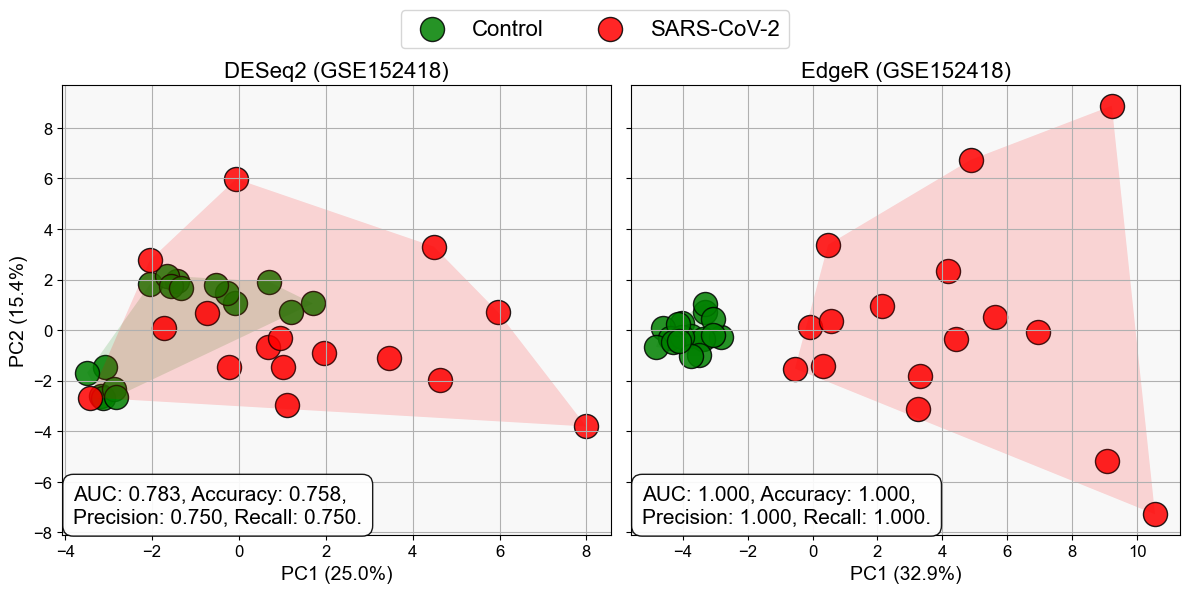

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score
from scipy.spatial import ConvexHull
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'

def draw_convex_hull(points, ax, color, alpha=0.2):
    if len(points) < 3:
        return
    hull = ConvexHull(points)
    vertices = np.append(hull.vertices, hull.vertices[0])
    ax.fill(points[vertices, 0], points[vertices, 1], color=color, alpha=alpha, lw=0)
test_set = 'GSE152418'
test_index = datasets.index(test_set) + 1
raw_file = f'{test_index}-{test_set}-Ready.csv'
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for ax, tool in zip(axes, ['DESeq2', 'EdgeR']):
    other = 'EdgeR' if tool == 'DESeq2' else 'DESeq2'
    train_sets = [d for d in datasets if d != test_set]
    tool_genes = set.intersection(*[load_sig_genes(tool, d) for d in train_sets])
    other_genes = set.intersection(*[load_sig_genes(other, d) for d in train_sets])
    unique_genes = tool_genes - other_genes
    auc, prec, rec, acc, n_genes, y_true, pc1, pc2, sample_names = evaluate_pca(unique_genes, raw_file)
    if y_true is None:
        ax.set_title(f'{tool}: Not enough genes', fontsize=14)
        continue
    raw_df = pd.read_csv(raw_file)
    raw_df.set_index('Gene Symbol', inplace=True)
    raw_df = raw_df.loc[raw_df.index.intersection(unique_genes)]
    data = raw_df.T
    labels = data.index.str.contains('SARS-CoV-2').astype(int)
    scaler = StandardScaler()
    scaled = scaler.fit_transform(data)
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(scaled)
    pc1, pc2 = (pcs[:, 0], pcs[:, 1])
    evr = pca.explained_variance_ratio_
    for label_value, label_name, color in [(0, 'Control', 'green'), (1, 'SARS-CoV-2', 'red')]:
        idx = labels == label_value
        ax.scatter(pc1[idx], pc2[idx], label=label_name, color=color, s=300, edgecolor='black', alpha=0.85)
        draw_convex_hull(np.vstack([pc1[idx], pc2[idx]]).T, ax, color=color, alpha=0.15)
    box_text = f'AUC: {auc:.3f}, Accuracy: {acc:.3f}, \nPrecision: {prec:.3f}, Recall: {rec:.3f}.'
    ax.text(0.02, 0.02, box_text, transform=ax.transAxes, fontsize=15, verticalalignment='bottom', horizontalalignment='left', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.9))
    ax.set_title(f'{tool} (GSE152418)', fontsize=16)
    ax.set_xlabel(f'PC1 ({evr[0] * 100:.1f}%)', fontsize=14)
    if ax is axes[0]:
        ax.set_ylabel(f'PC2 ({evr[1] * 100:.1f}%)', fontsize=14)
    ax.tick_params(labelsize=12)
    ax.grid(True)
    ax.set_facecolor('#f8f8f8')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()
